# ICS 2405: Knowledge-Based Systmes

## CONTEXT:
regularized linear regression: DecisionTreeRegressor. Ridge. LinearRegression. NuSVR. Lasso. KNeighborsRegressor


Regularization adds a penalty for model complexity to the loss function, creating a tradeoff between accuracy and simplicity to prevent overfitting.

## cost function structure:
```
Total Cost = Loss(predictions, actual) + λ × Complexity(weights)
```
where:
- **Loss**: measures prediction errors (e.g., sum of squared errors)
- **Complexity**: penalizes large weights to encourage simpler models
- **λ (lambda)**: controls tradeoff between loss and complexity

## two main regularization types:

### 1. **L1 Regularization (Lasso)**
- **complexity term**: sum of absolute weights `Σ|w|`
- **effect**: can force some weights to exactly zero → feature selection
- **cost function**: `Σ(wx - y)² + λΣ|w|`

### 2. **L2 Regularization (Ridge)**
- **complexity term**: sum of squared weights `Σw²`
- **effect**: shrinks weights toward zero but rarely exactly zero
- **cost function**: `Σ(wx - y)² + λΣw²`


In [1]:
#setup
from mlwpy import *
%matplotlib inline

diabetes = datasets.load_diabetes()

d_tts = skms.train_test_split(diabetes.data,
                              diabetes.target, 
                              test_size=.25,
                              random_state=42)

(diabetes_train_ftrs, diabetes_test_ftrs, 
 diabetes_train_tgt,  diabetes_test_tgt) = d_tts

In [2]:
weights = np.array([3.5, -2.1, .7])
print(np.sum(np.abs(weights)),
      np.sum(weights**2))

6.3 17.15


In [3]:
x_1 = np.arange(10)
m, b = 3, 2
w = np.array([m,b])

x = np.c_[x_1, np.repeat(1.0, 10)] # the plus-one trick

errors = np.tile(np.array([0.0, 1.0, 1.0, .5, .5]), 2)

print(errors * errors)
print(np.dot(errors, errors))

y_true = rdot(w,x)
y_msr  = y_true + errors

D = (x,y_msr)

[0.   1.   1.   0.25 0.25 0.   1.   1.   0.25 0.25]
5.0


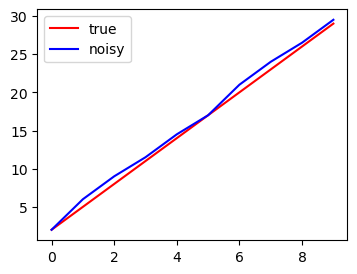

In [5]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(x_1, y_true, 'r', label='true')
ax.plot(x_1, y_msr , 'b', label='noisy')
ax.legend();

In [7]:
def sq_diff(a,b):
    return (a-b)**2

In [8]:
predictions = rdot(w,x)
np.sum(sq_diff(predictions, y_msr))

np.float64(5.0)

In [9]:
predictions = rdot(w,x)

loss = np.sum(sq_diff(predictions, y_msr))

complexity_1 = np.sum(np.abs(weights))
complexity_2 = np.sum(weights**2) # == np.dot(weights, weights)

cost_1 = loss + complexity_1
cost_2 = loss + complexity_2

print("Sum(abs) complexity:", cost_1)
print("Sum(sqr) complexity:", cost_2)

Sum(abs) complexity: 11.3
Sum(sqr) complexity: 22.15


In [10]:
predictions = rdot(w,x)
errors = np.sum(sq_diff(predictions, y_msr))
complexity_1 = np.sum(np.abs(weights))

C = .5
cost = errors + C * complexity_1
cost

np.float64(8.15)

## comments:
- **small λ**: emphasizes fitting data (low bias, high variance risk)
- **large λ**: emphasizes simple models (high bias, low variance)
- **regularization helps** when data is noisy or features are correlated
- **setting weights to zero** simplifies model by reducing effective parameters

## tradeoff interpretation
the regularization parameter λ represents:
- how much we value simplicity vs accuracy
- the relative cost of complexity compared to prediction errors
- a tuning knob between underfitting and overfitting

## applications
- `ridge regression`: when all features potentially contribute
- `lasso regression`: when suspecting many irrelevant features (sparse solutions)

In [11]:
models = [linear_model.Lasso(),            # L1 regularized; C=1.0
          linear_model.Ridge()]            # L2 regularized; C=1.0

for model in models:
    model.fit(diabetes_train_ftrs, diabetes_train_tgt)
    train_preds = model.predict(diabetes_train_ftrs)
    test_preds  = model.predict(diabetes_test_ftrs)
    print(get_model_name(model), 
          "\nTrain MSE:",metrics.mean_squared_error(diabetes_train_tgt, 
                                                    train_preds), 
          "\n Test MSE:", metrics.mean_squared_error(diabetes_test_tgt,  
                                                     test_preds))

Lasso 
Train MSE: 3947.905329714893 
 Test MSE: 3433.1554921199713
Ridge 
Train MSE: 3461.743744823801 
 Test MSE: 3105.4721464484733


# Support Vector Regression (SVR):

SVR modifies linear regression by using a loss function that ignores small errors (within a threshold ε) and only penalizes errors larger than ε.

## Hinge Loss for Regression
- **Standard absolute loss**: `|error|` → penalizes all errors equally
- **Hinge loss**: `max(|error| - ε, 0)` → ignores errors smaller than ε
- **Effect**: Creates an "ε-insensitive tube" where predictions within ±ε of actual are considered acceptable (zero loss)


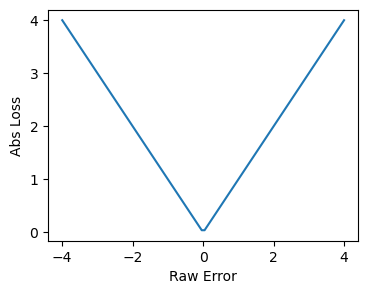

In [12]:
#  here, we don't ignore small errors
error = np.linspace(-4, 4, 100)
loss = np.abs(error)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(error, loss)

ax.set_xlabel('Raw Error')
ax.set_ylabel('Abs Loss');


## Mathematical Formulation
```
loss = max(|y_true - y_pred| - ε, 0)
```
Where:
- **ε (epsilon)**: Threshold for acceptable error (user-defined parameter)
- **Error**: Difference between predicted and actual value
- If |error| ≤ ε → loss = 0
- If |error| > ε → loss = |error| - ε

## Visual Interpretation
- Creates a "band" or "tube" of width 2ε around the regression line
- Points inside the tube incur zero loss
- Points outside the tube incur loss proportional to their distance from the tube boundary


In [13]:
an_error = .75
abs_error = abs(an_error)
if abs_error < 1.0:
    the_loss = 0.0
else:
    the_loss = abs_error
print(the_loss)

0.0


In [14]:
an_error = 0.75
adj_error = abs(an_error) - 1.0
if adj_error < 0.0:
    the_loss = 0.0
else:
    the_loss = adj_error
print(the_loss)

0.0


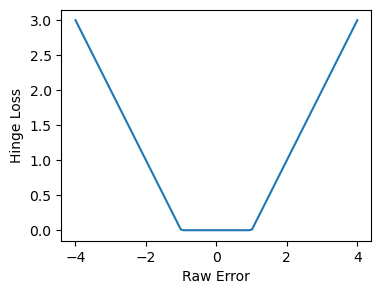

In [15]:
error = np.linspace(-4, 4, 100)

# here, we ignore errors up to 1.0 ... take bigger value
loss = np.maximum(np.abs(error) - 1.0, 
                  np.zeros_like(error))

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(error, loss)

ax.set_xlabel("Raw Error")
ax.set_ylabel("Hinge Loss");

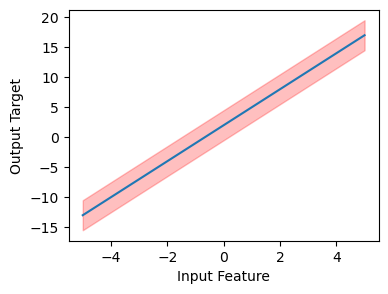

In [16]:
threshold = 2.5

xs = np.linspace(-5,5,100)
ys_true = 3 * xs + 2

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs, ys_true)
ax.fill_between(xs, ys_true-threshold, ys_true+threshold, 
                 color=(1.0,0,0,.25))

ax.set_xlabel('Input Feature')
ax.set_ylabel('Output Target');

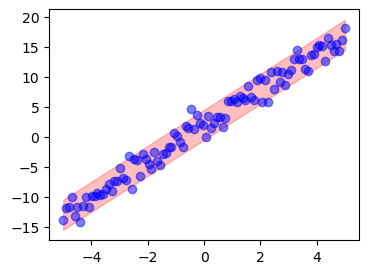

In [17]:
threshold = 2.5

xs = np.linspace(-5,5,100)
ys = 3 * xs + 2 + np.random.normal(0, 1.5, 100)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(xs, ys, 'o',  color=(0,0,1.0,.5))
ax.fill_between(xs, ys_true - threshold, ys_true + threshold, 
                 color=(1.0,0,0,.25));



## Connection to Support Vector Classifiers (SVC)
- Similar to SVC's margin concept: only points outside the margin contribute to loss
- Maximizes margin while allowing some errors (soft margin)
- Uses same "hinge" mechanism but adapted for regression

## Key Insights
1. **Robust to small errors**: Unlike MSE or MAE, small errors are completely ignored
2. **Sparse solution**: Only points outside ε-tube (support vectors) influence the model
3. **Parameter ε controls**: 
   - Large ε: Wider tube, more errors ignored, simpler model
   - Small ε: Narrow tube, more points penalized, potentially more complex model

## Applications
- When small errors are acceptable/tolerable
- When data has noise but underlying pattern is linear
- When robustness to outliers is desired (points far outside ε-tube still have linear penalty, not quadratic)

## implementation **sklearn**: `SVR(kernel='linear', epsilon=ε_value)`

---------------
# Progression from Linear Regression to SVR

> mathematical progression

1. **GOF (Ordinary) Linear Regression**
   - Loss: L2 (Sum of squared errors)
   - Penalty: None
   - Formula: `Σ(y - wx)²`

2. **Lasso Regression (L1-regularized)**
   - Loss: L2 (Sum of squared errors)
   - Penalty: L1 (Sum of absolute weights)
   - Formula: `Σ(y - wx)² + CΣ|w|`

3. **Ridge Regression (L2-regularized)**
   - Loss: L2 (Sum of squared errors)
   - Penalty: L2 (Sum of squared weights)
   - Formula: `Σ(y - wx)² + CΣw²`

4. **Support Vector Regression (SVR)**
   - Loss: Hinge (ε-insensitive)
   - Penalty: L2 (Sum of squared weights)
   - Formula: `Σmax(|y - wx| - ε, 0) + CΣw²`

## differences:

| Method | Loss Function | Regularization | Key Feature |
|--------|--------------|----------------|-------------|
| Ordinary LR | Squared error (L2) | None | Best fit without constraints |
| Lasso | Squared error (L2) | L1 (absolute) | Can zero out weights (feature selection) |
| Ridge | Squared error (L2) | L2 (squared) | Shrinks weights smoothly |
| SVR | Hinge (ε-insensitive) | L2 (squared) | Ignores small errors (<ε) |


In [18]:
# hyper-parameters for the scenario
C, epsilon = 1.0, .25

# parameters
weights = np.array([1.3])

In [19]:
# prediction, error, loss
predictions = rdot(weights, xs.reshape(-1, 1))
errors = ys - predictions

loss_sse   = np.sum(errors ** 2)
loss_sae   = np.sum(np.abs(errors))
loss_hinge = np.sum(np.max(np.abs(errors) - epsilon, 0))

In [20]:
# complexity penalty for regularization
complexity_saw = np.sum(np.abs(weights))
complexity_ssw = np.sum(weights**2)

In [21]:
# cost
cost_gof_regression   = loss_sse   + 0.0
cost_L1pen_regression = loss_sse   + C * complexity_saw
cost_L2pen_regression = loss_sse   + C * complexity_ssw
cost_sv_regression    = loss_hinge + C * complexity_ssw

## just do it - the svr way:



1. **Choosing Between Methods**:
   - use cross-validation to select best method for specific dataset
   - GOF linear regression: good baseline, simple interpretation
   - Lasso: when suspecting many irrelevant features (sparse solutions)
   - Ridge: when features are correlated, moderate regularization
   - SVR: when small errors are acceptable, robust to noise

2. **Implementation in sklearn**:
   - `LinearRegression`: ordinary least squares
   - `Lasso`: L1-regularized (alpha = C)
   - `Ridge`: L2-regularized (alpha = C)
   - `SVR`: ε-SVR (set epsilon)
   - `NuSVR`: ν-SVR (set nu = proportion of support vectors)

3. **parameter**:
   - **C (alpha)**: controls tradeoff between loss and regularization
   - **ε (epsilon)**: error tolerance in SVR (ignores errors ≤ ε)
   - **ν (nu)**: proportion of support vectors in NuSVR

## algorithms:
- **for many features, suspect irrelevant ones**: try Lasso
- **correlated features, all potentially useful**: try Ridge  
- **noisy data, small errors acceptable**: try SVR
- **simple baseline**: ordinary linear regression
- **always**: use cross-validation to compare and select

In [22]:
svrs = [svm.SVR(gamma='auto'),   # default epsilon=0.1 
        svm.NuSVR(gamma='auto')] # default nu=0.5

for model in svrs:
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
                  .predict(diabetes_test_ftrs))
    print(metrics.mean_squared_error(diabetes_test_tgt, preds))

5516.346256574164
5527.520207785892


# Piecewise Constant Regression


Piecewise constant regression divides the input space into predetermined regions and predicts a constant value (horizontal line) for each region, useful for discontinuous target patterns.

## Motivation
- Linear regression assumes smoothness (small input changes → small output changes)
- Real-world problems like cash rounding create stair-step patterns
- Piecewise constant regression handles these discontinuities by using different constants in different regions

## Key Characteristics
- **Predetermined splits**: Boundaries between regions are fixed (unlike k-NN which adapts to data density)
- **Constant predictions**: Each region predicts a single value (horizontal line)
- **Interpretability**: Each region's prediction is easy to understand



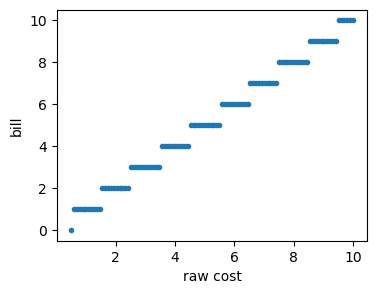

In [24]:
raw_bill = np.linspace(.5, 10.0, 100)
collected = np.round(raw_bill)

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(raw_bill, collected, '.')
ax.set_xlabel("raw cost")
ax.set_ylabel("bill");

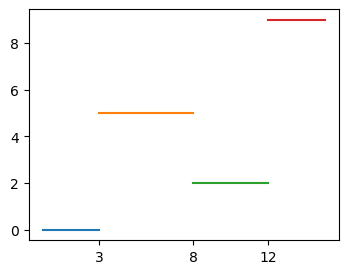

In [25]:
fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot([0,3],   [0,0],
        [3,8],   [5,5],
        [8,12],  [2,2],
        [12,15], [9,9])
ax.set_xticks([3,8,12]);


## Comparison with k-NN Regression
| Aspect | Piecewise Constant Regression | k-NN Regression |
|--------|-----------------------------|-----------------|
| Boundaries | Fixed, predetermined | Adaptive, based on data density |
| Prediction basis | Region membership | Nearest training examples |
| Domain knowledge | Can incorporate known breakpoints | Fully data-driven |

## Implementation (Custom sklearn Estimator)
```python
class PiecewiseConstantRegression(BaseEstimator, RegressorMixin):
    def __init__(self, cut_points=None):
        self.cut_points = cut_points
    
    def fit(self, X, y):
        # 1. Determine cut points (if not provided)
        # 2. Recode features: map values to region indicators
        # 3. Fit linear regression on indicator variables
        pass
    
    def predict(self, X):
        # 1. Map input to region indicators
        # 2. Use region constants for prediction
        pass
```

## Implementation Details
1. **Region mapping**: Use `np.searchsorted()` to determine which region a value belongs to
2. **Feature recoding**: Convert continuous feature to indicator variables (one-hot encoding of regions)
3. **Model fitting**: Use `LinearRegression(fit_intercept=False)` on indicator variables to get region constants

## Considerations
- **Split point sensitivity**: Model performance highly depends on cut point locations
- **Domain knowledge**: Useful when natural breakpoints exist (e.g., tax brackets, price tiers)
- **Cross-validation**: Essential for tuning split points when no domain knowledge exists
- **Single feature limitation**: Current implementation works only with one input feature

## Extensions
- **Piecewise linear regression**: Allow slopes within regions (not just constants)
- **Continuity constraints**: Force prediction values to match at region boundaries
- **Smoothness constraints**: Require gentle transitions between regions
- **Multiple features**: Generalize to higher-dimensional input spaces


In [26]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import (check_X_y, 
                                      check_array, 
                                      check_is_fitted)

class PiecewiseConstantRegression(BaseEstimator, RegressorMixin):
    def __init__(self, cut_points=None):
        self.cut_points = cut_points

    def fit(self, X, y):
        X, y = check_X_y(X,y)
        assert X.shape[1] == 1 # one variable only
        
        if self.cut_points is None:
            n = (len(X) // 10) + 1
            qtiles = np.linspace(0.0, 1.0, n+2)[1:-1]
            self.cut_points =  np.percentile(X, qtiles, axis=1)
        else:
            # ensure cutpoints in-order and in range of X
            assert np.all(self.cut_points[:-1] < self.cut_points[1:])
            assert (X.min() < self.cut_points[0] and 
                    self.cut_points[-1] < X.max())

        recoded_X = self._recode(X)
        # even though the _inner_ model is fit without an intercept
        # our piecewise model *does* have an constant term (but see notes)
        self.coeffs_ = (linear_model.LinearRegression(fit_intercept=False)
                                    .fit(recoded_X, y).coef_)
    def _recode(self, X):
        cp = self.cut_points
        n_pieces = len(cp) + 1
        recoded_X = np.eye(n_pieces)[np.searchsorted(cp, X.flat)]
        return recoded_X
    
    def predict(self, X):
        check_is_fitted(self, 'coeffs_')
        X = check_array(X) 
        recoded_X = self._recode(X)
        return rdot(self.coeffs_, recoded_X)

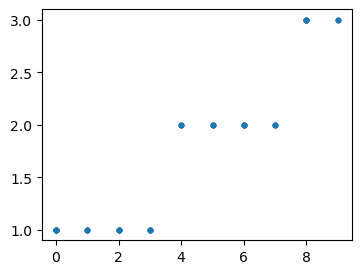

In [27]:
ftr = np.random.randint(0,10,(100,1)).astype(np.float64)
cp = np.array([3,7])
tgt = np.searchsorted(cp, ftr.flat) + 1

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(ftr, tgt, '.');

In [28]:
# here, we're giving our self all the help we can by using
# the same cut points as our data were generated with
model = PiecewiseConstantRegression(cut_points=np.array([3, 7]))
model.fit(ftr, tgt)
preds = model.predict(ftr)
print("Predictions equal target?", np.allclose(preds, tgt))

Predictions equal target? True



## Takeaway
Piecewise constant regression provides interpretable predictions for discontinuous patterns but requires careful selection of split points, either through domain knowledge or cross-validation.

----
# Regression Trees

decision trees adapted for regression predict constant numerical values (e.g., mean) in leaf nodes instead of class labels, automatically determining split points to minimize prediction error.

## working:
1. **splitting criterion**: Choose splits that minimize squared error (or other loss functions)
2. **greedy algorithm**: Builds tree by making locally optimal splits at each node
3. **leaf predictions**: Each leaf predicts a constant value (typically the mean of target values in that region)

## characteristics
- **Automatic split selection**: Unlike piecewise constant regression with fixed splits, trees data-adaptively choose splits
- **Interpretability**: Tree structure shows decision rules leading to predictions
- **Handles discontinuities**: Can model non-smooth relationships effectively

## sklearn
```python
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor(max_depth=5)
dtree.fit(X_train, y_train)
predictions = dtree.predict(X_test)
```


In [29]:
dtrees = [tree.DecisionTreeRegressor(max_depth=md) for md in [1, 3, 5, 10]]

for model in dtrees:
    preds = (model.fit(diabetes_train_ftrs, diabetes_train_tgt)
                  .predict(diabetes_test_ftrs))
    mse = metrics.mean_squared_error(diabetes_test_tgt, preds)
    fmt = "{} {:2d} {:4.0f}"
    print(fmt.format(get_model_name(model),
                     model.get_params()['max_depth'],
                     mse))

DecisionTreeRegressor  1 4341
DecisionTreeRegressor  3 3512
DecisionTreeRegressor  5 4284
DecisionTreeRegressor 10 5189



## complexity control
- **shallow trees** (small max_depth): underfit, high bias, low variance
- **deep trees** (large max_depth): overfit, low bias, high variance
- **optimal depth**: Found via cross-validation; balances bias and variance

## comparison with piecewise constant regression
| aspect | regression trees | piecewise constant regression |
|--------|------------------|-----------------------------|
| split determination | data-driven, automatic | user-specified or cross-validated |
| region shape | axis-aligned rectangles (multi-dimensional) | predefined intervals (1D) |
| adaptability | adapts to data density and patterns | fixed regardless of data distribution |

## practical considerations
1. **overfitting tendency**: trees can easily overfit with unlimited depth
2. **hyperparameter tuning**: critical to control via `max_depth`, `min_samples_split`, `min_samples_leaf`
3. **interpretability**: trade-off between model complexity and interpretability


regression trees provide an automated way to perform piecewise constant prediction that adapts to the data's structure, but require careful complexity control to avoid overfitting.

## PRACTIC PSET

In [27]:
student_df = pd.read_csv('data/portugese_student_numeric.csv')
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt  = student_df['G3']

In [28]:
student_tts = skms.train_test_split(student_ftrs, student_tgt)

(student_train_ftrs, student_test_ftrs,
 student_train_tgt,  student_test_tgt) = student_tts

In [29]:
old_school = [linear_model.LinearRegression(),
              neighbors.KNeighborsRegressor(n_neighbors=3),
              neighbors.KNeighborsRegressor(n_neighbors=10)]

In [30]:
# L1, L2 penalized (abs, sqr) C=1.0 for both
penalized_lr = [linear_model.Lasso(), 
                linear_model.Ridge()]

# defaults are epsilon=.1 and nu=.5, respectively
svrs = [svm.SVR(), svm.NuSVR()] 

dtrees = [tree.DecisionTreeRegressor(max_depth=md) for md in [1, 3, 5, 10]]

reg_models = old_school + penalized_lr + svrs + dtrees

In [31]:
def rms_error(actual, predicted):
    ' root-mean-squared-error function '
    # lesser values are better (a<b ... a better)
    mse = metrics.mean_squared_error(actual, predicted)    
    return np.sqrt(mse)
rms_scorer = metrics.make_scorer(rms_error)

In [32]:
scaler = skpre.StandardScaler()

scores = {}
for model in reg_models:
    pipe = pipeline.make_pipeline(scaler, model)
    preds = skms.cross_val_predict(pipe, 
                                   student_ftrs, student_tgt, 
                                   cv=10)
    key = (get_model_name(model) + 
           str(model.get_params().get('max_depth', "")) + 
           str(model.get_params().get('n_neighbors', "")))
    scores[key] = rms_error(student_tgt, preds)

df = pd.DataFrame.from_dict(scores, orient='index').sort_values(0)
df.columns=['RMSE']
display(df)

,RMSE
DecisionTreeRegressor1,4.3192
Ridge,4.3646
LinearRegression,4.3653
NuSVR,4.3896
SVR,4.4062
DecisionTreeRegressor3,4.4298
Lasso,4.4375
KNeighborsRegressor10,4.4869
DecisionTreeRegressor5,4.7410
KNeighborsRegressor3,4.8915


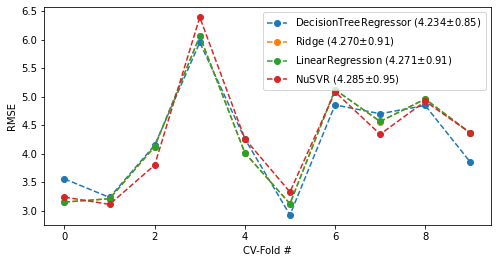

In [33]:
better_models = [tree.DecisionTreeRegressor(max_depth=1),
                 linear_model.Ridge(),
                 linear_model.LinearRegression(),
                 svm.NuSVR()]

fig, ax = plt.subplots(1, 1, figsize=(8,4))
for model in better_models:
    pipe = pipeline.make_pipeline(scaler, model)    
    cv_results = skms.cross_val_score(pipe, 
                                      student_ftrs, student_tgt, 
                                      scoring = rms_scorer, 
                                      cv=10)

    my_lbl = "{:s} ({:5.3f}$\pm${:.2f})".format(get_model_name(model), 
                                                cv_results.mean(), 
                                                cv_results.std())
    ax.plot(cv_results, 'o--', label=my_lbl)
    ax.set_xlabel('CV-Fold #')
    ax.set_ylabel("RMSE")
    ax.legend()